# Notebook 01 - Analyse Exploratoire et Nettoyage des Données

**Objectif du notebook** :  
Ce premier notebook pose les fondations du projet en explorant le dataset California Housing Prices et en effectuant un nettoyage rigoureux des données. L'objectif est de comprendre la structure des données, identifier les anomalies et préparer un dataset propre pour la phase de feature engineering.

**Livrables attendus** :
- Une compréhension claire de la distribution des variables
- Un dataset nettoyé sans valeurs manquantes ni incohérences
- Des insights sur les relations entre variables et prix médian des maisons
- Une base solide pour la modélisation prédictive

## 1. Chargement et Exploration Initiale

**Objectif** :
- Chargement du dataset brut (`housing.csv`)
- Première inspection : dimensions, types de données, valeurs manquantes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import numpy as np
import geopandas as gpd
import contextily as cx

file_path = '../data/raw/housing.csv'

df = pd.read_csv(file_path)

print(f"Dimensions: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

print("Types de données:")
type_counts = df.dtypes.value_counts()
for dtype, count in type_counts.items():
    print(f"   - {dtype}: {count} colonnes")

print("\nValeurs manquantes:")
missing = df.isnull().sum()
if missing.sum() > 0:
    for col in missing[missing > 0].index:
        print(f"   • {col:25} {missing[col]:5}")
else:
    print("   Aucune valeur manquante")

print("\nStatistiques (variables numériques):")
print(df.describe().T[['mean', 'std', 'min', '50%', 'max']].round(2))


cat_cols = df.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    print("\nVariables catégorielles:")
    for col in cat_cols:
        print(f"   - {col}: {df[col].nunique()} valeurs uniques")

Dimensions: 20,640 lignes × 10 colonnes
Types de données:
   - float64: 9 colonnes
   - object: 1 colonnes

Valeurs manquantes:
   • total_bedrooms              207

Statistiques (variables numériques):
                         mean        std       min        50%        max
longitude             -119.57       2.00   -124.35    -118.49    -114.31
latitude                35.63       2.14     32.54      34.26      41.95
housing_median_age      28.64      12.59      1.00      29.00      52.00
total_rooms           2635.76    2181.62      2.00    2127.00   39320.00
total_bedrooms         537.87     421.39      1.00     435.00    6445.00
population            1425.48    1132.46      3.00    1166.00   35682.00
households             499.54     382.33      1.00     409.00    6082.00
median_income            3.87       1.90      0.50       3.53      15.00
median_house_value  206855.82  115395.62  14999.00  179700.00  500001.00

Variables catégorielles:
   - ocean_proximity: 5 valeurs uniques


**Observations clés** :
- **20 640 lignes** représentant des quartiers californiens
- **10 colonnes** : 9 numériques + 1 catégorielle
- **207 valeurs manquantes** sur `total_bedrooms` (~1% du dataset)

**Statistiques importantes** :
- `median_house_value` : variable cible (prix médian des maisons d'un quartier)
- `median_income` : revenu médian des habitants (en milliers de dollars)
- Variables géographiques : `latitude`, `longitude`, `ocean_proximity`
- Variables structurelles : `total_rooms`, `total_bedrooms`, `population`, `households`
- Variable temporelle : `housing_median_age` (âge médian des maisons)

## 2. Analyse de la Distribution des Variables Numériques

### 2.1 Boxplots (détection des outliers)

**Pourquoi** :
- Identifier rapidement les valeurs aberrantes
- Comparer les échelles entre variables
- Détecter des plafonds artificiels dans les données

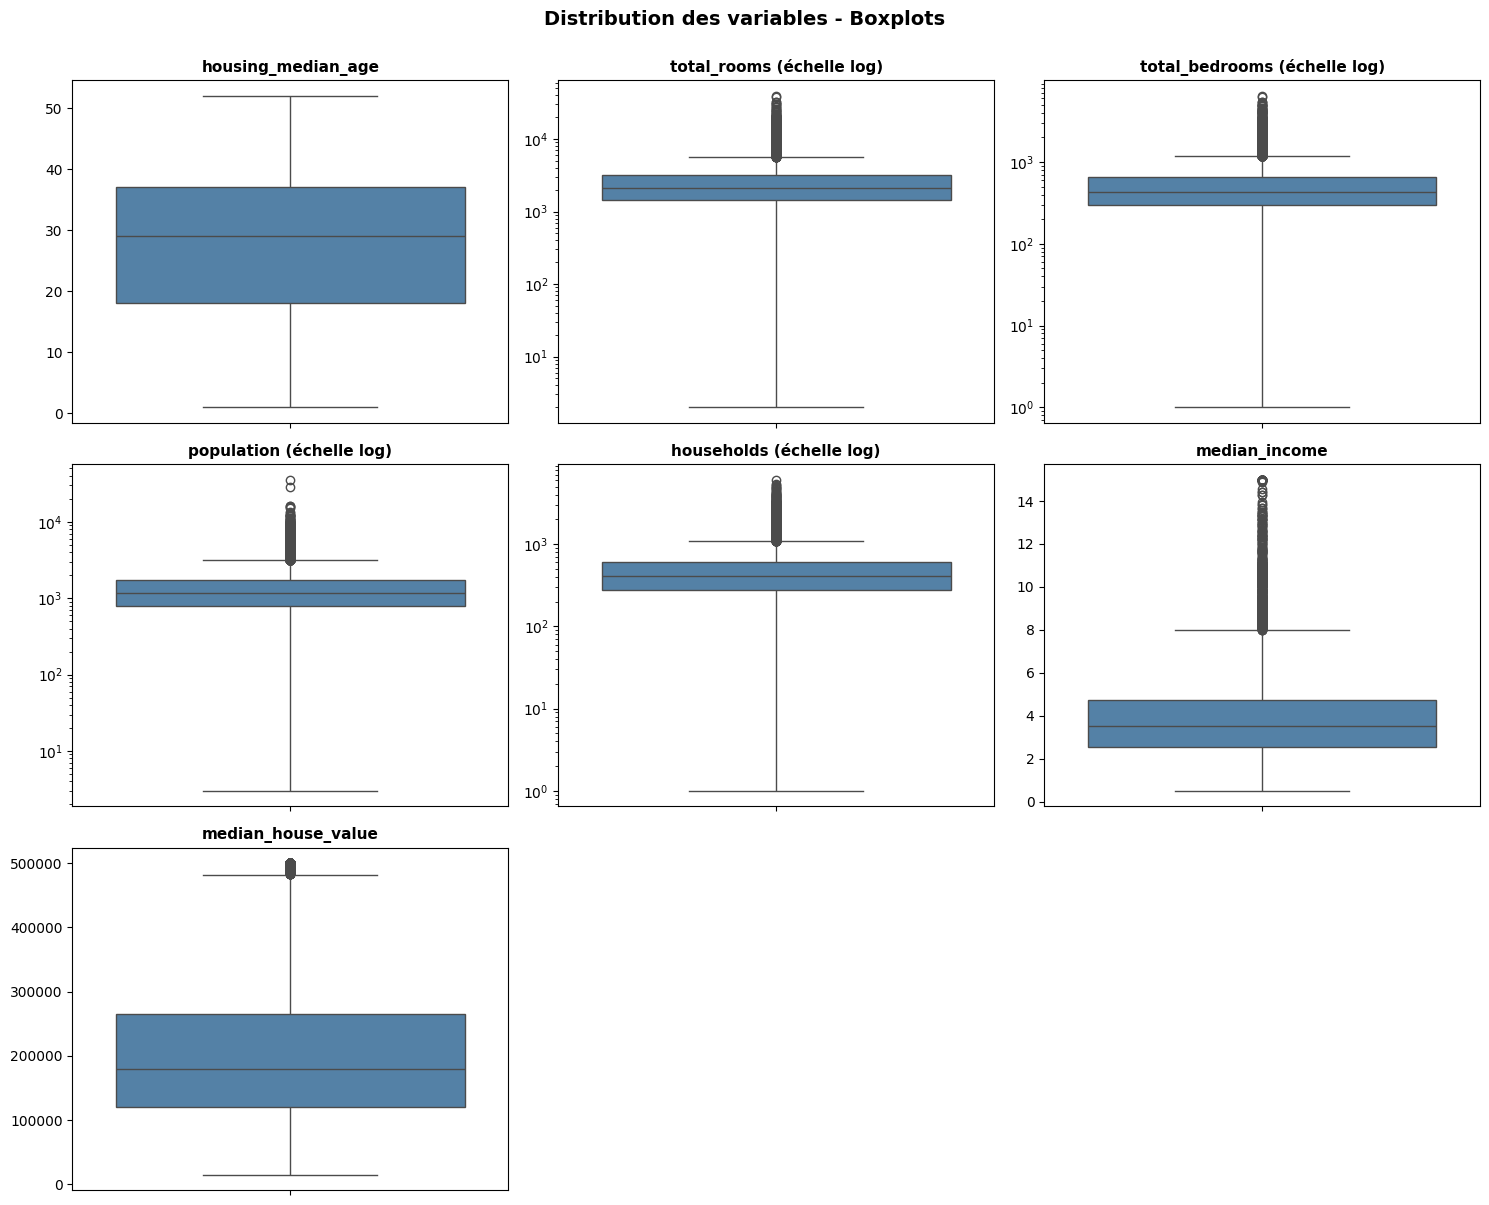

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

columns_num = [col for col in df.select_dtypes(include=['number']).columns 
               if col not in ['latitude', 'longitude']]
log_cols = ['total_rooms', 'total_bedrooms', 'population', 'households']

for i, cols in enumerate(columns_num):
    sns.boxplot(y=df[cols], ax=axes[i], color='steelblue')
    if cols in log_cols:
        axes[i].set_yscale('log')
        axes[i].set_title(f"{cols} (échelle log)", fontsize=11, fontweight='bold')
    else:
        axes[i].set_title(f"{cols}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution des variables - Boxplots', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Observations** :
- `median_house_value` : distribution plafonnée à 500,001$
- `median_income` : plafond à 15,000 ($) → même problème
- Variables `total_rooms`, `total_bedrooms`, `population`, `households` : distributions très asymétriques avec nombreux outliers = transformation logarithmique

**Actions requises** :
- Supprimer les lignes avec plafonds artificiels
- Envisager des transformations logarithmiques pour les variables asymétriques

### 2.2 Courbes de Densité (KDE)

**Pourquoi** :
- Analyser la forme réelle de la distribution
- Identifier les asymétries fines
- Évaluer si une transformation est pertinente

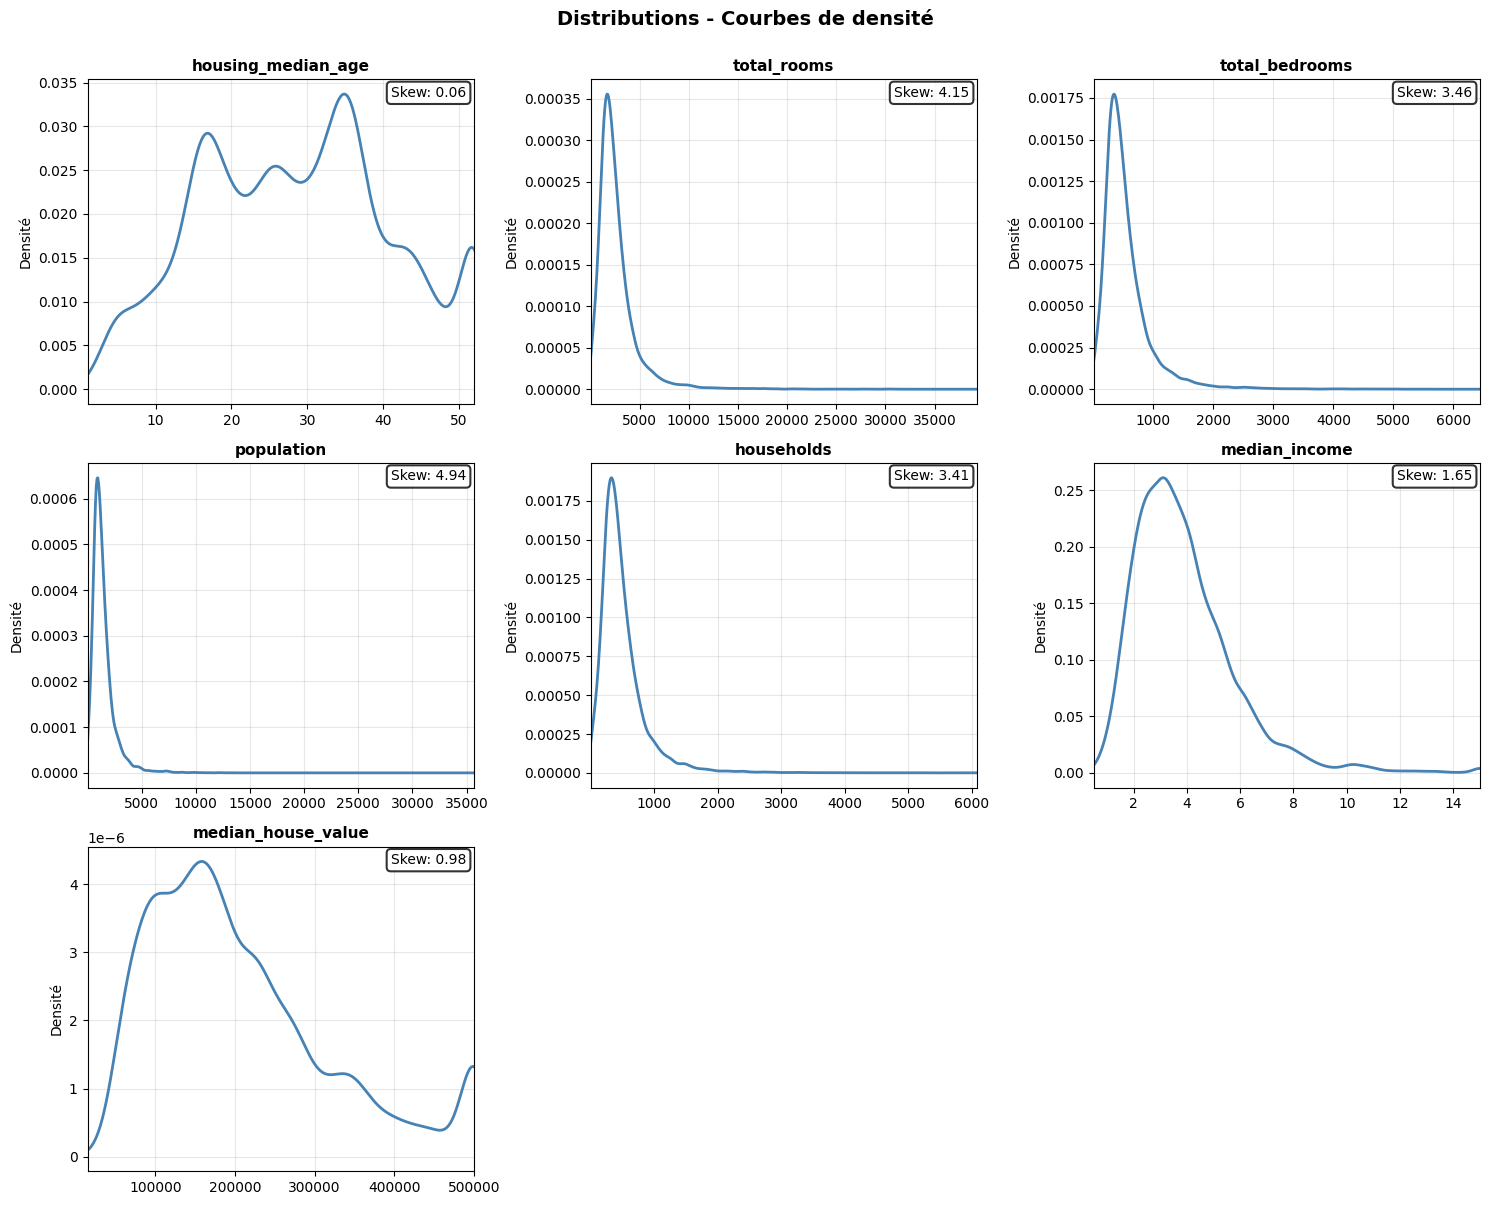

In [8]:
columns_num = [col for col in df.select_dtypes(include=['number']).columns 
               if col not in ['latitude', 'longitude']]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, cols in enumerate(columns_num):
    df[cols].plot(kind='kde', ax=axes[i], color='steelblue', linewidth=2)
    axes[i].set_title(f"{cols}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Densité")
    axes[i].set_xlabel("")
    axes[i].grid(alpha=0.3)
    axes[i].set_xlim(df[cols].min(), df[cols].max())
    skew = df[cols].skew()
    axes[i].text(0.98, 0.98, f'Skew: {skew:.2f}',
                transform=axes[i].transAxes,
                fontsize=10,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', 
                         edgecolor='black', linewidth=1.5, alpha=0.8))
    
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions - Courbes de densité', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Observations** :
- **Asymétrie (skewness)** : Les variables de comptage (`total_rooms`, `total_bedrooms`, `population`, `households`) sont fortement asymétriques à droite
- `median_house_value` : distribution relativement normale
- `housing_median_age` : distribution bimodale (deux pics) → présence de populations distinctes

**Actions requises** :  
Les variables asymétriques nécessiteront des transformations logarithmiques pour améliorer les performances du modèle.

## 3. Répartition des Variables Catégorielles

### 3.1 housing_median_age_bracket

housing_median_age_bracket
1-10     1569
11-20    4724
21-30    4852
31-40    5617
41-50    2557
>50      1321
Name: count, dtype: int64


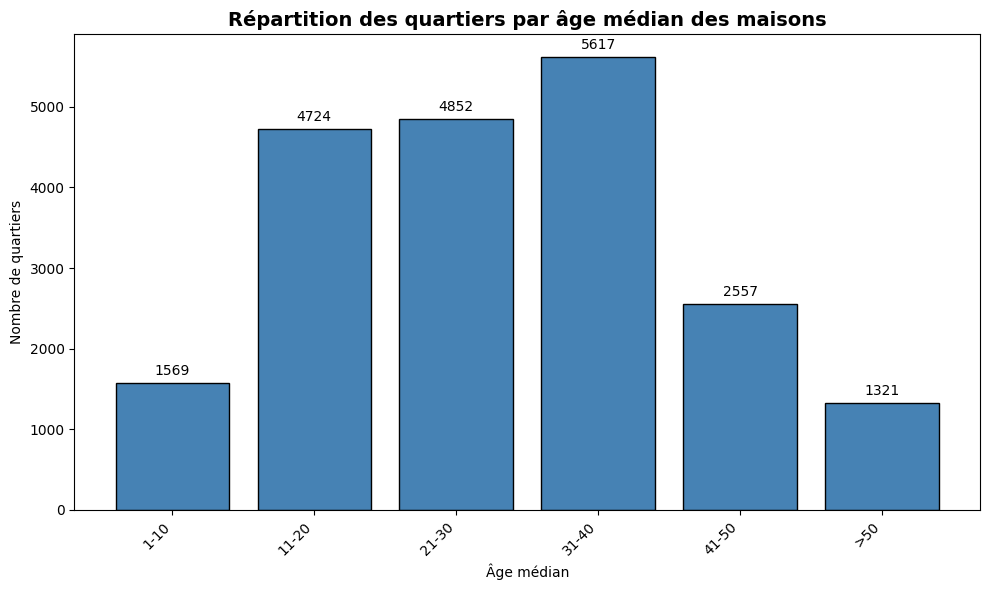

In [16]:
bracket = df.copy()

bins = [0, 10, 20, 30, 40, 50, float('inf')]

labels = ['1-10', '11-20', '21-30', '31-40', '41-50', '>50']

bracket['housing_median_age_bracket'] = pd.cut(
    bracket['housing_median_age'],
    bins=bins,
    labels=labels,
    right=True  # True signifie que la borne supérieure est incluse
)

value_counts = bracket['housing_median_age_bracket'].value_counts().sort_index()
print(value_counts)

plt.figure(figsize=(10,6))
plt.bar(value_counts.index, value_counts.values, color='steelblue', edgecolor='black')
plt.title("Répartition des quartiers par âge médian des maisons", fontsize=14, fontweight='bold')
plt.ylabel("Nombre de quartiers")
plt.xlabel("Âge médian")
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(value_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Observations** :
- **6 catégories** :
  - 1-10 ans : 1 569 quartiers (8%)
  - 11-20 ans : 4 724 quartiers (23%)
  - 21-30 ans : 4 852 quartiers (23%)
  - 31-40 ans : 5 617 quartiers (27%)
  - 41-50 ans : 2 257 quartiers (12%)
  - >50 ans : 1 321 quartiers (7%)

**Résultats** :
- La plupart des maisons en Californie ont entre 11 et 40 ans
- Peu de maisons neuves (1-10 ans) et anciennes (>50 ans)

### 3.2 ocean_proximity

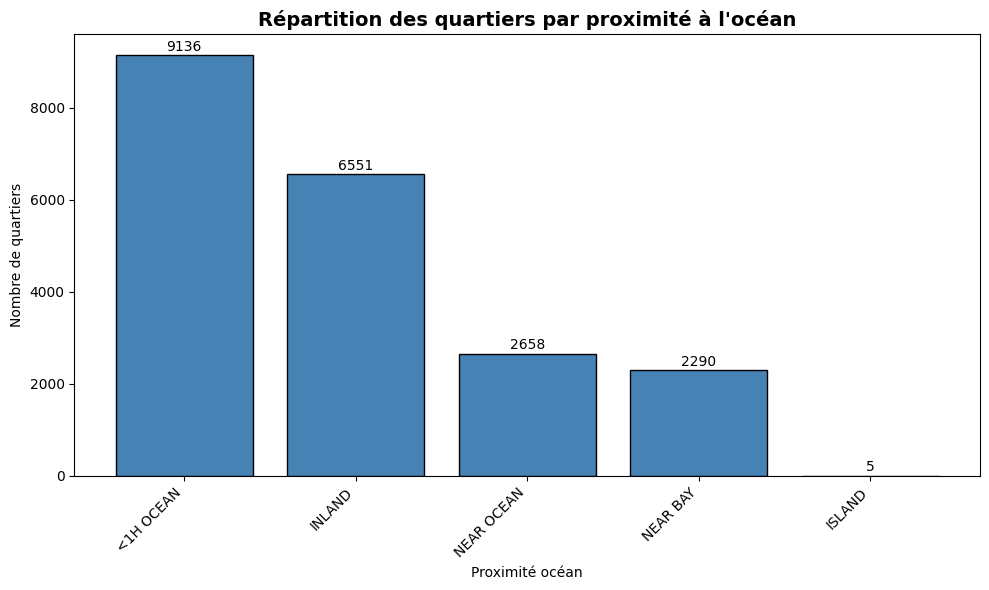


Variable catégorielle : 5 catégories
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(10, 6))
value_counts = df['ocean_proximity'].value_counts()
plt.bar(value_counts.index, value_counts.values, color='steelblue', edgecolor='black')
plt.title("Répartition des quartiers par proximité à l'océan", fontsize=14, fontweight='bold')
plt.ylabel("Nombre de quartiers")
plt.xlabel("Proximité océan")
plt.xticks(rotation=45, ha='right')

# Ajouter les valeurs sur les barres
for i, v in enumerate(value_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nVariable catégorielle : {df['ocean_proximity'].nunique()} catégories")
print(value_counts)

**Observations** :
- **5 catégories** :
  - `<1H OCEAN` : 9 136 quartiers (44%)
  - `INLAND` : 6 551 quartiers (32%)
  - `NEAR OCEAN` : 2 658 quartiers (13%)
  - `NEAR BAY` : 2 290 quartiers (11%)
  - `ISLAND` : 5 quartiers seulement (0.02%)

**Insights** :
- La catégorie `ISLAND` est extrêmement rare → risque de surapprentissage
- `<1H OCEAN` domine largement : la majorité des logements sont proches de la côte

**Résultat** :  
La proximité à l'océan sera probablement une variable clé dans la prédiction du prix.

## 4. Analyse Géographique : Visualisation des Populations Géographiques

<Figure size 1200x800 with 0 Axes>

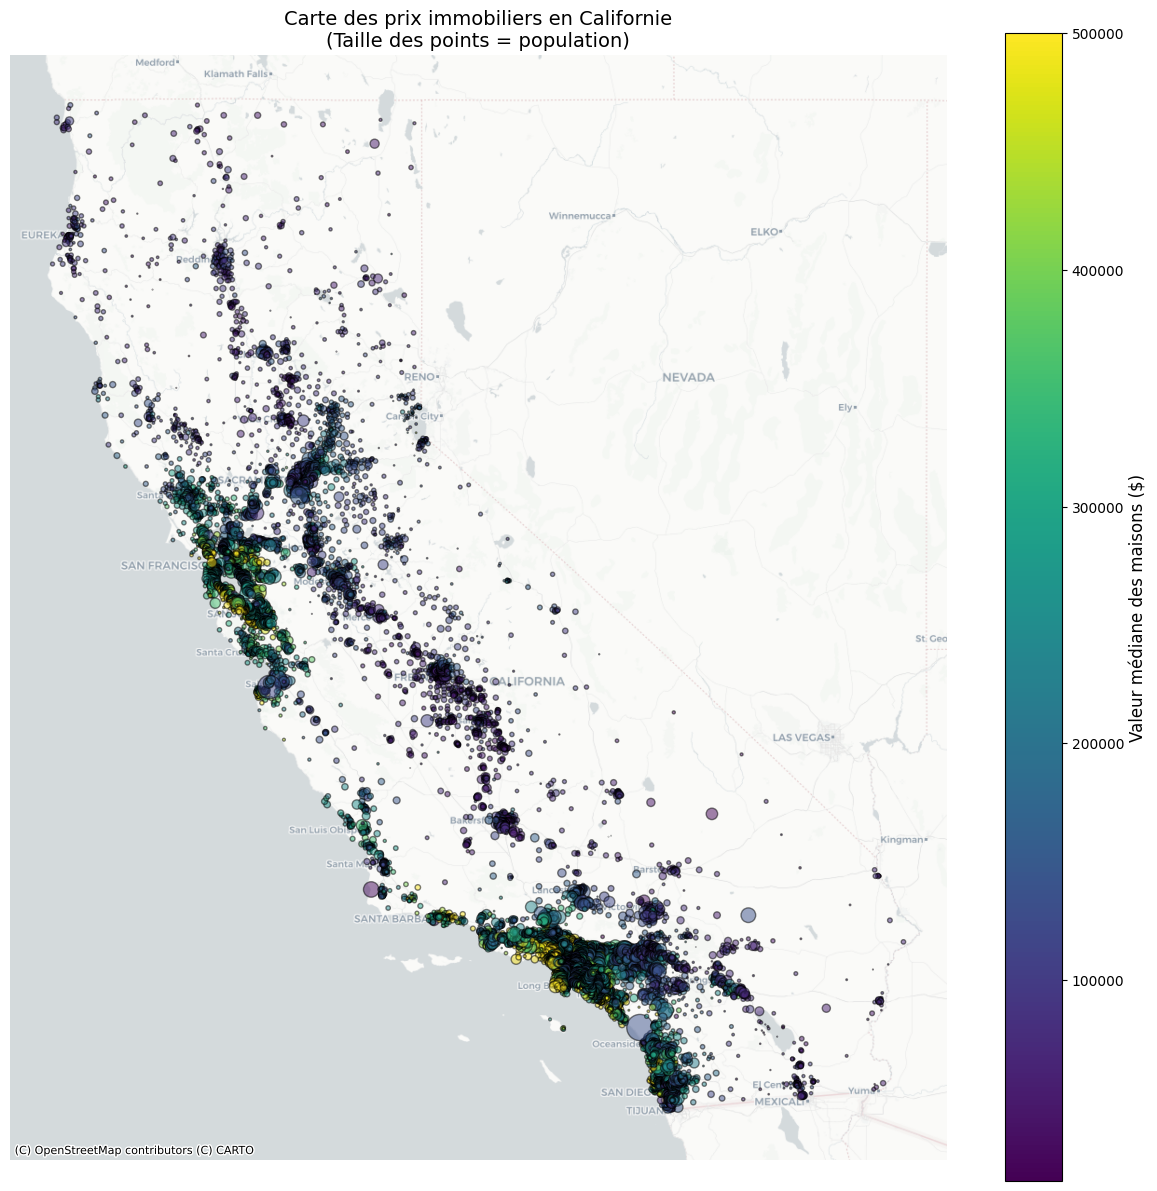

In [10]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"  # latitude / longitude
)

gdf = gdf.to_crs(epsg=3857)

plt.figure(figsize=(12, 8))

fig, ax = plt.subplots(figsize=(12, 12))

plot = gdf.plot(
    ax=ax,
    markersize=gdf['population']/100,
    column='median_house_value',  
    cmap='viridis',    
    alpha=0.5,
    edgecolor='black',
    legend=True
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron 
)
ax.set_aspect('equal')
ax.set_title(
    "Carte des prix immobiliers en Californie\n(Taille des points = population)",
    fontsize=14
)

cbar = plot.get_figure().axes[-1]
cbar.set_ylabel("Valeur médiane des maisons ($)", fontsize=12)

ax.set_axis_off()
plt.tight_layout()
plt.show()

**Visualisation** :
- **Taille des points** = population du quartier
- **Couleur** = valeur médiane des maisons du quartier
- **Fond de carte** : CartoDB Positron pour le contexte géographique

**Insights visuels** :
- Les quartiers chers (jaune/vert) se concentrent autour des grandes villes côtières : San Francisco, Los Angeles, San Diego
- L'intérieur des terres (`INLAND`) affiche des prix plus bas (violet/bleu foncé)
- Deux hubs distincts autour de LA et SF
- Sacramento ne se démarque ni par son prix ni par sa population

**Conclusion** :  
La géographie est un facteur déterminant du prix. Les features basées sur la localisation seront essentielles.

## 5. Impact des Variables Catégorielles sur les Prix

### 5.1 Impact de l'âge médian

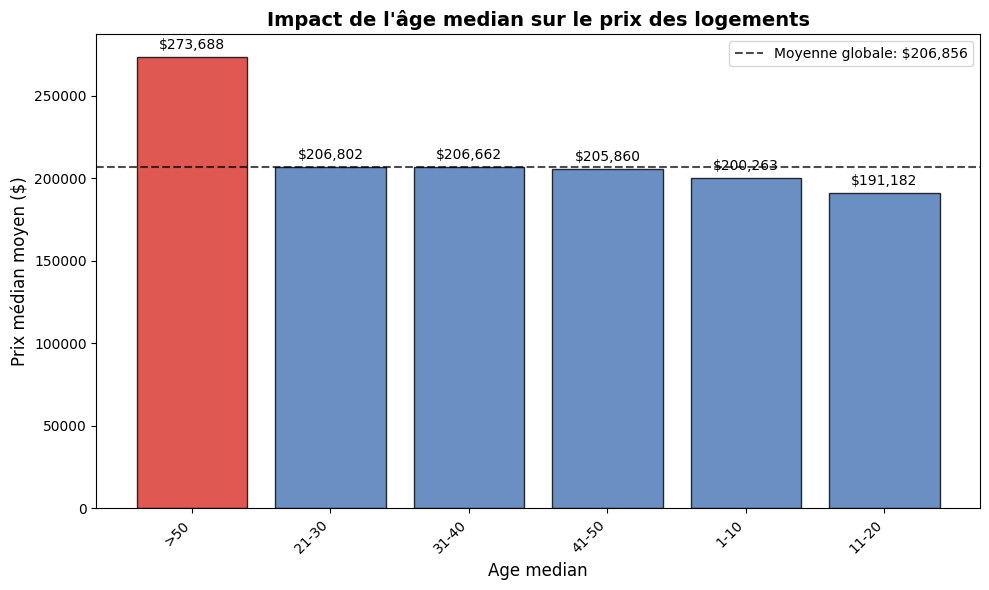


Prix moyens par catégorie :
housing_median_age_bracket
>50      $273,688
21-30    $206,802
31-40    $206,662
41-50    $205,860
1-10     $200,263
11-20    $191,182
Name: median_house_value, dtype: object


In [20]:
mean_prices = bracket.groupby('housing_median_age_bracket', observed=True)['median_house_value'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
colors = ['#d73027' if i == 0 else '#4575b4' for i in range(len(mean_prices))]
plt.bar(mean_prices.index, mean_prices.values, color=colors, edgecolor='black', alpha=0.8)

plt.xlabel('Age median', fontsize=12)
plt.ylabel('Prix médian moyen ($)', fontsize=12)
plt.title('Impact de l\'âge median sur le prix des logements', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Ajouter valeurs
for i, v in enumerate(mean_prices.values):
    plt.text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=10)

plt.axhline(y=bracket['median_house_value'].mean(), color='black', linestyle='--', 
            label=f'Moyenne globale: ${bracket["median_house_value"].mean():,.0f}', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print("\nPrix moyens par catégorie :")
print(mean_prices.apply(lambda x: f'${x:,.0f}'))

**Observations** :
- Les quartiers avec des maisons entre **21 et 40 ans** ont des prix proches de la moyenne
- Les quartiers avec des maisons entre **1 et 20 ans** ont des prix légèrement plus bas
- Les quartiers avec des maisons **anciennes (>50 ans)** ont des prix bien plus élevés (~30% de hausse)

**Résultats** :
- Ce graphique montre une **relation non linéaire** entre le prix et l'âge
- Le prix augmente lorsque les maisons d'un quartier sont anciennes

### 5.2 Impact de la proximité océan

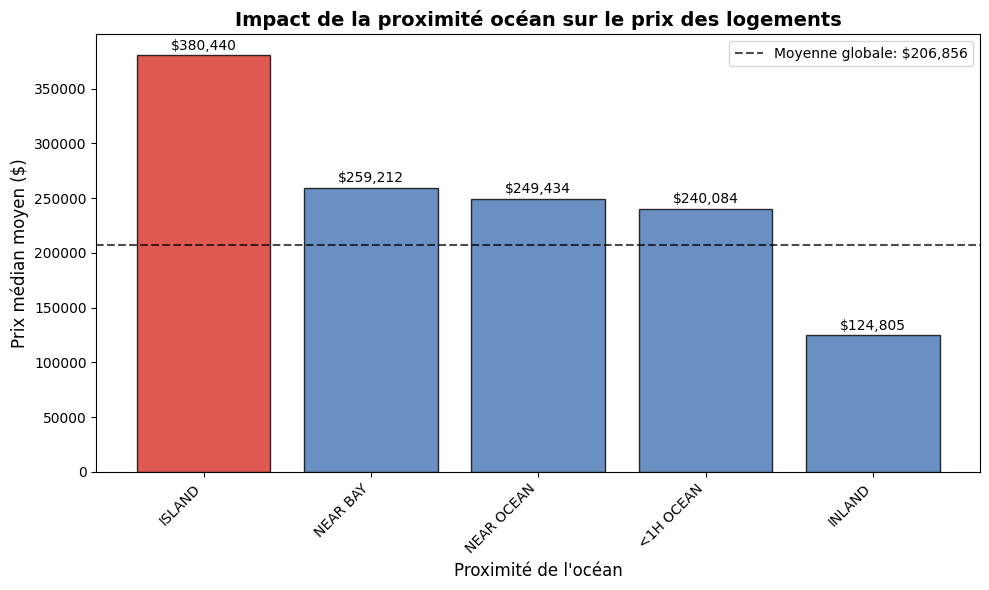


Prix moyens par catégorie :
ocean_proximity
ISLAND        $380,440
NEAR BAY      $259,212
NEAR OCEAN    $249,434
<1H OCEAN     $240,084
INLAND        $124,805
Name: median_house_value, dtype: object


In [11]:
mean_prices = df.groupby('ocean_proximity')['median_house_value'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#d73027' if i == 0 else '#4575b4' for i in range(len(mean_prices))]
plt.bar(mean_prices.index, mean_prices.values, color=colors, edgecolor='black', alpha=0.8)

plt.xlabel('Proximité de l\'océan', fontsize=12)
plt.ylabel('Prix médian moyen ($)', fontsize=12)
plt.title('Impact de la proximité océan sur le prix des logements', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Ajouter valeurs
for i, v in enumerate(mean_prices.values):
    plt.text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=10)

plt.axhline(y=df['median_house_value'].mean(), color='black', linestyle='--', 
            label=f'Moyenne globale: ${df["median_house_value"].mean():,.0f}', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print("\nPrix moyens par catégorie :")
print(mean_prices.apply(lambda x: f'${x:,.0f}'))

**Observations** :
- **~85% de différence** entre `INLAND` et les zones côtières
- `ISLAND` : prix très élevé mais seulement 5 observations → peu fiable statistiquement
- Hiérarchie claire : proximité océan = prix élevé

**Action requise** :  
Encoder `ocean_proximity` avec un ordre ordinal (1=INLAND, 2=<1H OCEAN, 3=NEAR OCEAN, 4=NEAR BAY, 5=ISLAND) pour capturer cette relation.

## 6. Impact des Variables Numériques sur le Prix

**Action** :  
Première approche pour capturer les relations linéaires entre les variables numériques et `median_house_value`.

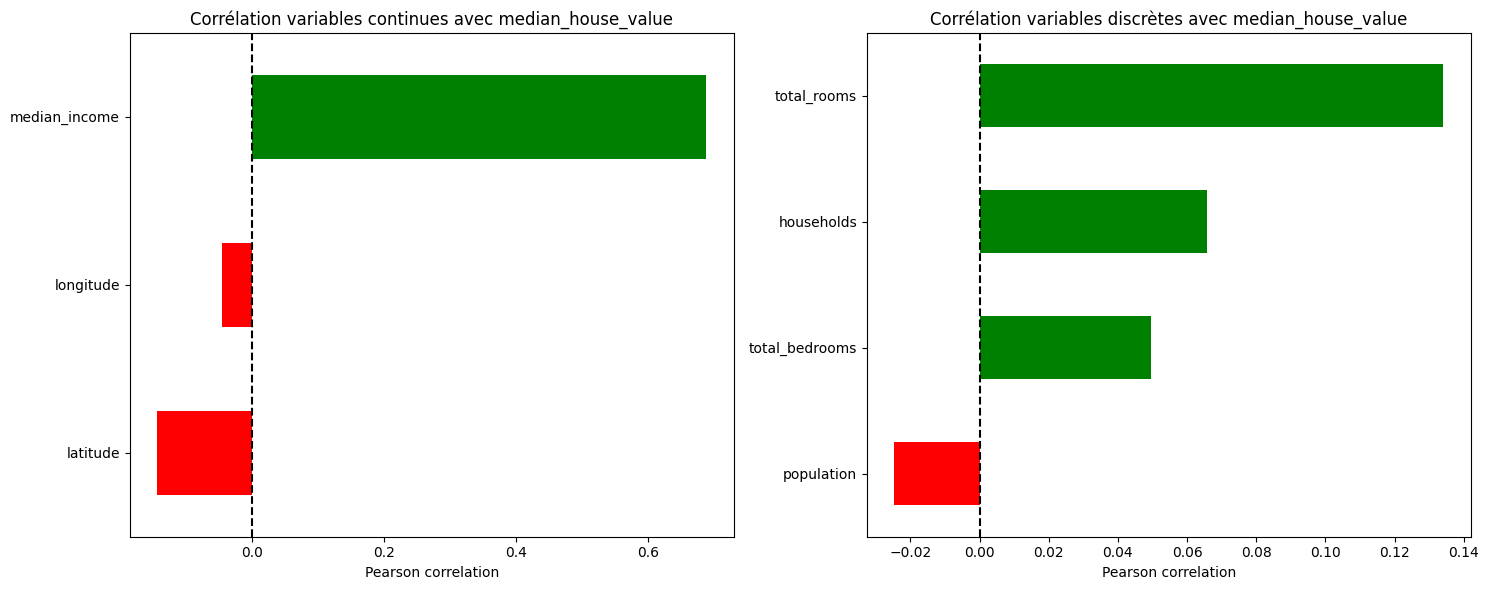

In [10]:
corr_target_cont = df[
    ['median_income', 'longitude', 'latitude']
].corrwith(df['median_house_value'])

corr_target_disc = df[
    ['total_rooms', 'total_bedrooms', 'households', 'population']
].corrwith(df['median_house_value'])

colors_cont = ['green' if val > 0 else 'red' for val in corr_target_cont.sort_values()]
colors_disc = ['green' if val > 0 else 'red' for val in corr_target_disc.sort_values()]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes = axes.flatten()

# Axe 0 : continues
corr_target_cont.sort_values().plot(kind='barh', color=colors_cont, ax=axes[0])
axes[0].set_title('Corrélation variables continues avec median_house_value')
axes[0].set_xlabel('Pearson correlation')
axes[0].axvline(0, color='black', linestyle='--')

# Axe 1 : discrètes
corr_target_disc.sort_values().plot(kind='barh', color=colors_disc, ax=axes[1])
axes[1].set_title('Corrélation variables discrètes avec median_house_value')
axes[1].set_xlabel('Pearson correlation')
axes[1].axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

**Observations** :
- `median_income` est **fortement corrélé** à `median_house_value` → cette variable seule explique environ **36%** de la variance de la cible
- `latitude` est faiblement corrélée (~5%) → la Californie est un État étendu verticalement, cela fait sens
- Les variables de comptage n'ont pas de relations linéaires évidentes avec la cible

**Actions** :
- Prioriser `median_income` et des features dérivées pour le modèle
- Normaliser les variables de comptage (par maison, par personne, par ménage) pour extraire des relations plus significatives

## 7. Nettoyage des Données

### 7.1 Traitement des valeurs manquantes

**Stratégie** :
- `total_bedrooms` : 207 valeurs manquantes (1%)
- Imputation par la **médiane du dataset complet**

**Limite** :  
On pourrait imputer par médiane locale (même zone géographique), mais cela complexifie le processus sans gain majeur pour 1% de données.

In [12]:
init_shape = df.shape

print(f"Valeurs manquantes total_bedrooms : {df['total_bedrooms'].isnull().sum()}")

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

print(f"Après imputation : {df['total_bedrooms'].isnull().sum()} manquantes\n")

Valeurs manquantes total_bedrooms : 207
Après imputation : 0 manquantes



### 7.2 Gestion des plafonds

In [13]:
n_before = len(df)
df = df[df['median_house_value'] < 500001]
n_after = len(df)
print(f"Retiré {n_before - n_after} lignes avec median_house_value = 500001 (plafond)\n")

n_before = len(df)
df = df[df['median_income'] < 15.0001]
n_after = len(df)
print(f"Retiré {n_before - n_after} lignes avec median_income = 15.0001 (plafond)\n")

Retiré 965 lignes avec median_house_value = 500001 (plafond)

Retiré 3 lignes avec median_income = 15.0001 (plafond)



**Actions** :
- Retrait des lignes avec `median_house_value` = 500 001 → **965 lignes** (~5%)
- Retrait des lignes avec `median_income` = 15.0001 → **3 lignes** supplémentaires
- `housing_median_age` a un plafond à 52 ans → catégorisation ultérieure (variable discrète, interprétation plus simple)

**Justification** :
- Ces valeurs sont des **plafonds artificiels** imposés lors de la collecte des données
- Les conserver biaiserait le modèle en créant une fausse concentration

### 7.3 Vérification de cohérence logique

In [14]:
invalid = df[df['total_bedrooms'] > df['total_rooms']]
if len(invalid) > 0:
    print(f"{len(invalid)} lignes avec bedrooms > total rooms")
    df = df[df['total_bedrooms'] <= df['total_rooms']]

print()

invalid = df[df['households'] > df['population']]
if len(invalid) > 0:
    print(f"{len(invalid)} lignes avec households > population")
    df = df[df['households'] <= df['population']]
    
print()
print(f"Dimensions avant nettoyage : {init_shape}\n")
print(f"Dimensions après nettoyage : {df.shape}\n")

5 lignes avec bedrooms > total rooms

3 lignes avec households > population

Dimensions avant nettoyage : (20640, 10)

Dimensions après nettoyage : (19664, 10)



**Règles appliquées** :
- `total_bedrooms` ≤ `total_rooms`
- `households` ≤ `population` (un ménage = au moins 1 personne)

**Résultat** :
- **5 lignes** avec `bedrooms` > `total_rooms`
- **3 lignes** supplémentaires avec `households` > `population`

**Action** : Suppression de ces **8 lignes incohérentes**.

## 8. Sauvegarde du Dataset Nettoyé

In [15]:
df.to_csv('../data/preprocessed/01_housing_cleaned.csv', index=False)

print("Dataset nettoyé sauvegardé")
print(f"Shape : {df.shape}")
print(f"Features : {df.columns.tolist()}")
print(f"Fichier : ../data/preprocessed/01_housing_cleaned.csv")

Dataset nettoyé sauvegardé
Shape : (19664, 10)
Features : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
Fichier : ../data/preprocessed/01_housing_cleaned.csv


**Fichier créé** : `../data/preprocessed/01_housing_cleaned.csv`

**Dimensions finales** : 19 664 lignes × 10 colonnes

**Réduction** : ~5% du dataset initial (976 lignes supprimées)

## Synthèse

**Exploration complète du dataset** :
- Distributions, outliers, géographie, relations entre variables

**Nettoyage rigoureux** :
- Valeurs manquantes (imputation médiane)
- Plafonds artificiels (suppression)
- Incohérences logiques (suppression)

**Insights clés** :
- La géographie est déterminante → proximité de l'eau et des grandes villes sont des features essentielles
- Beaucoup de variables nécessitent des transformations logarithmiques
- Le revenu médian d'un quartier est le prédicteur le plus fort du prix médian des maisons

**Prochaines étapes** :  
Feature engineering pour créer des variables plus puissantes (ratios, transformations, encodages).